In [1]:
import pygmt
import pandas as pd
import matplotlib.pyplot as plt
import verde as vd

Given that the original dataset is around 40 GB, we must apply preprocessing steps such as decimation or chunked loading to handle it efficiently with pandas.

Import the real dataset and decimate it from 100 Hz to 1 Hz.

In [2]:
# arquivo = '/home/arthur/Documentos/ANP_MAG/0001_PARANA_28058_med_proc_01.asc'
# output_file = "../data/parana-basin-magnetic-processed.csv"
# media_cada = 100
# porcentagem_minima = 0.7
# ncols = 20

# with open(arquivo) as f:
#     with open(output_file, "w") as output:
#         processando = []
#         linha_de_voo_atual = None
#         for i, linha in enumerate(f):
#             # # Tirar o break depois dos testes
#             # if i >= 10000000:
#             #     break
#             if linha.startswith("/"):
#                 output.write(linha.replace("/", "#"))
#                 continue
#             if linha.startswith("FID"):
#                 output.write(linha)
#                 continue
#             partes = linha.strip().split(",")
#             # Tem uma linha com MAGIGRF zuada
#             # try:
#             #     float(partes[17])
#             # except ValueError:
#             #     continue
#             if len(partes) != ncols:
#                 continue
#             linha_de_voo = partes[2]
#             if linha_de_voo_atual is None:
#                 linha_de_voo_atual = linha_de_voo
#             if len(processando) == media_cada or (linha_de_voo != linha_de_voo_atual and len(processando) >= porcentagem_minima * media_cada):
#                 partes_media = []
#                 for j in range(ncols):
#                     if j in {3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}:
#                         partes_media.append(f"{np.mean([float(l[j]) for l in processando]):.8f}")
#                     else:
#                         partes_media.append(processando[len(processando) // 2][j])
#                 output.write(",".join(partes_media) + "\n")
#                 processando = []            
#             if linha_de_voo != linha_de_voo_atual:                        
#                 linha_de_voo_atual = linha_de_voo
#                 processando = []
#             processando.append(partes)  

Use pandas to load the real data file, then print and plot it.

In [3]:
caminho = "../data/parana-basin-magnetic-processed.csv"

df = pd.read_csv(caminho, sep=',', comment="#")
df.columns = ['FID','ESTACAO','LINHA','X','Y','LATITUDE','LONGITUDE','DATA','HORA','GPSALT','BARO','MAGBRU','MAGCOM','MAGBASE','MAGCOR','MAGNIV','MAGMIC','MAGIGRF','IGRF','MDT']

lat = df['LATITUDE']
lon = df['LONGITUDE']
magigrf = df['MAGIGRF']

In [4]:
df

,FID,ESTACAO,LINHA,X,Y,LATITUDE,LONGITUDE,DATA,HORA,GPSALT,BARO,MAGBRU,MAGCOM,MAGBASE,MAGCOR,MAGNIV,MAGMIC,MAGIGRF,IGRF,MDT
0,51,PT-MEP,10530,255224.6365,7.372759e+06,-23.737515,-53.401242,2010/03/12,02:54:46.50,1808.2891,1880.3881,22608.16175,22609.51267,22728.61950,22613.04125,22618.83678,22620.29658,-52.48224,22672.77872,328.5415
1,151,PT-MEP,10530,255225.5474,7.372679e+06,-23.738237,-53.401246,2010/03/12,02:54:47.50,1808.5220,1880.5468,22608.64038,22609.97994,22728.61780,22613.49026,22619.28550,22620.75751,-51.99339,22672.75089,322.4540
2,251,PT-MEP,10530,255226.1866,7.372599e+06,-23.738959,-53.401253,2010/03/12,02:54:48.50,1808.6819,1880.9050,22609.06762,22610.39596,22728.61642,22613.89924,22619.69425,22621.17844,-51.54464,22672.72300,316.3407
3,351,PT-MEP,10530,255226.6241,7.372519e+06,-23.739680,-53.401262,2010/03/12,02:54:49.50,1808.7876,1881.0422,22609.48424,22610.78737,22728.61540,22614.28528,22620.08003,22621.57621,-51.11878,22672.69509,310.4413
4,451,PT-MEP,10530,255226.9427,7.372439e+06,-23.740401,-53.401272,2010/03/12,02:54:50.50,1808.8495,1881.1163,22609.83922,22611.16128,22728.61500,22614.65915,22620.45367,22621.95878,-50.70816,22672.66713,306.3588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2256986,225793072,PR-SSB,39220,-45063.9792,7.689668e+06,-20.813103,-56.232598,2009/10/21,09:49:36.50,1793.2019,1781.8954,22806.91996,22806.46429,22757.57800,22780.87616,23774.35057,23774.35057,977.60079,22796.74972,233.3664
2256987,225793172,PR-SSB,39220,-45140.7230,7.689666e+06,-20.813097,-56.233333,2009/10/21,09:49:37.50,1792.6253,1780.8524,22806.91521,22806.45448,22757.57800,22780.88789,23774.35978,23774.35978,977.61296,22796.74680,235.4558
2256988,225793272,PR-SSB,39220,-45217.4906,7.689664e+06,-20.813090,-56.234068,2009/10/21,09:49:38.50,1792.1400,1780.3300,22806.87126,22806.42254,22757.57773,22780.81665,23774.28595,23774.28595,977.54204,22796.74387,237.5541
2256989,225793372,PR-SSB,39220,-45294.2826,7.689662e+06,-20.813084,-56.234803,2009/10/21,09:49:39.50,1791.6784,1779.8100,22806.84270,22806.39667,22757.57700,22780.80015,23774.26685,23774.26685,977.52593,22796.74096,239.6379


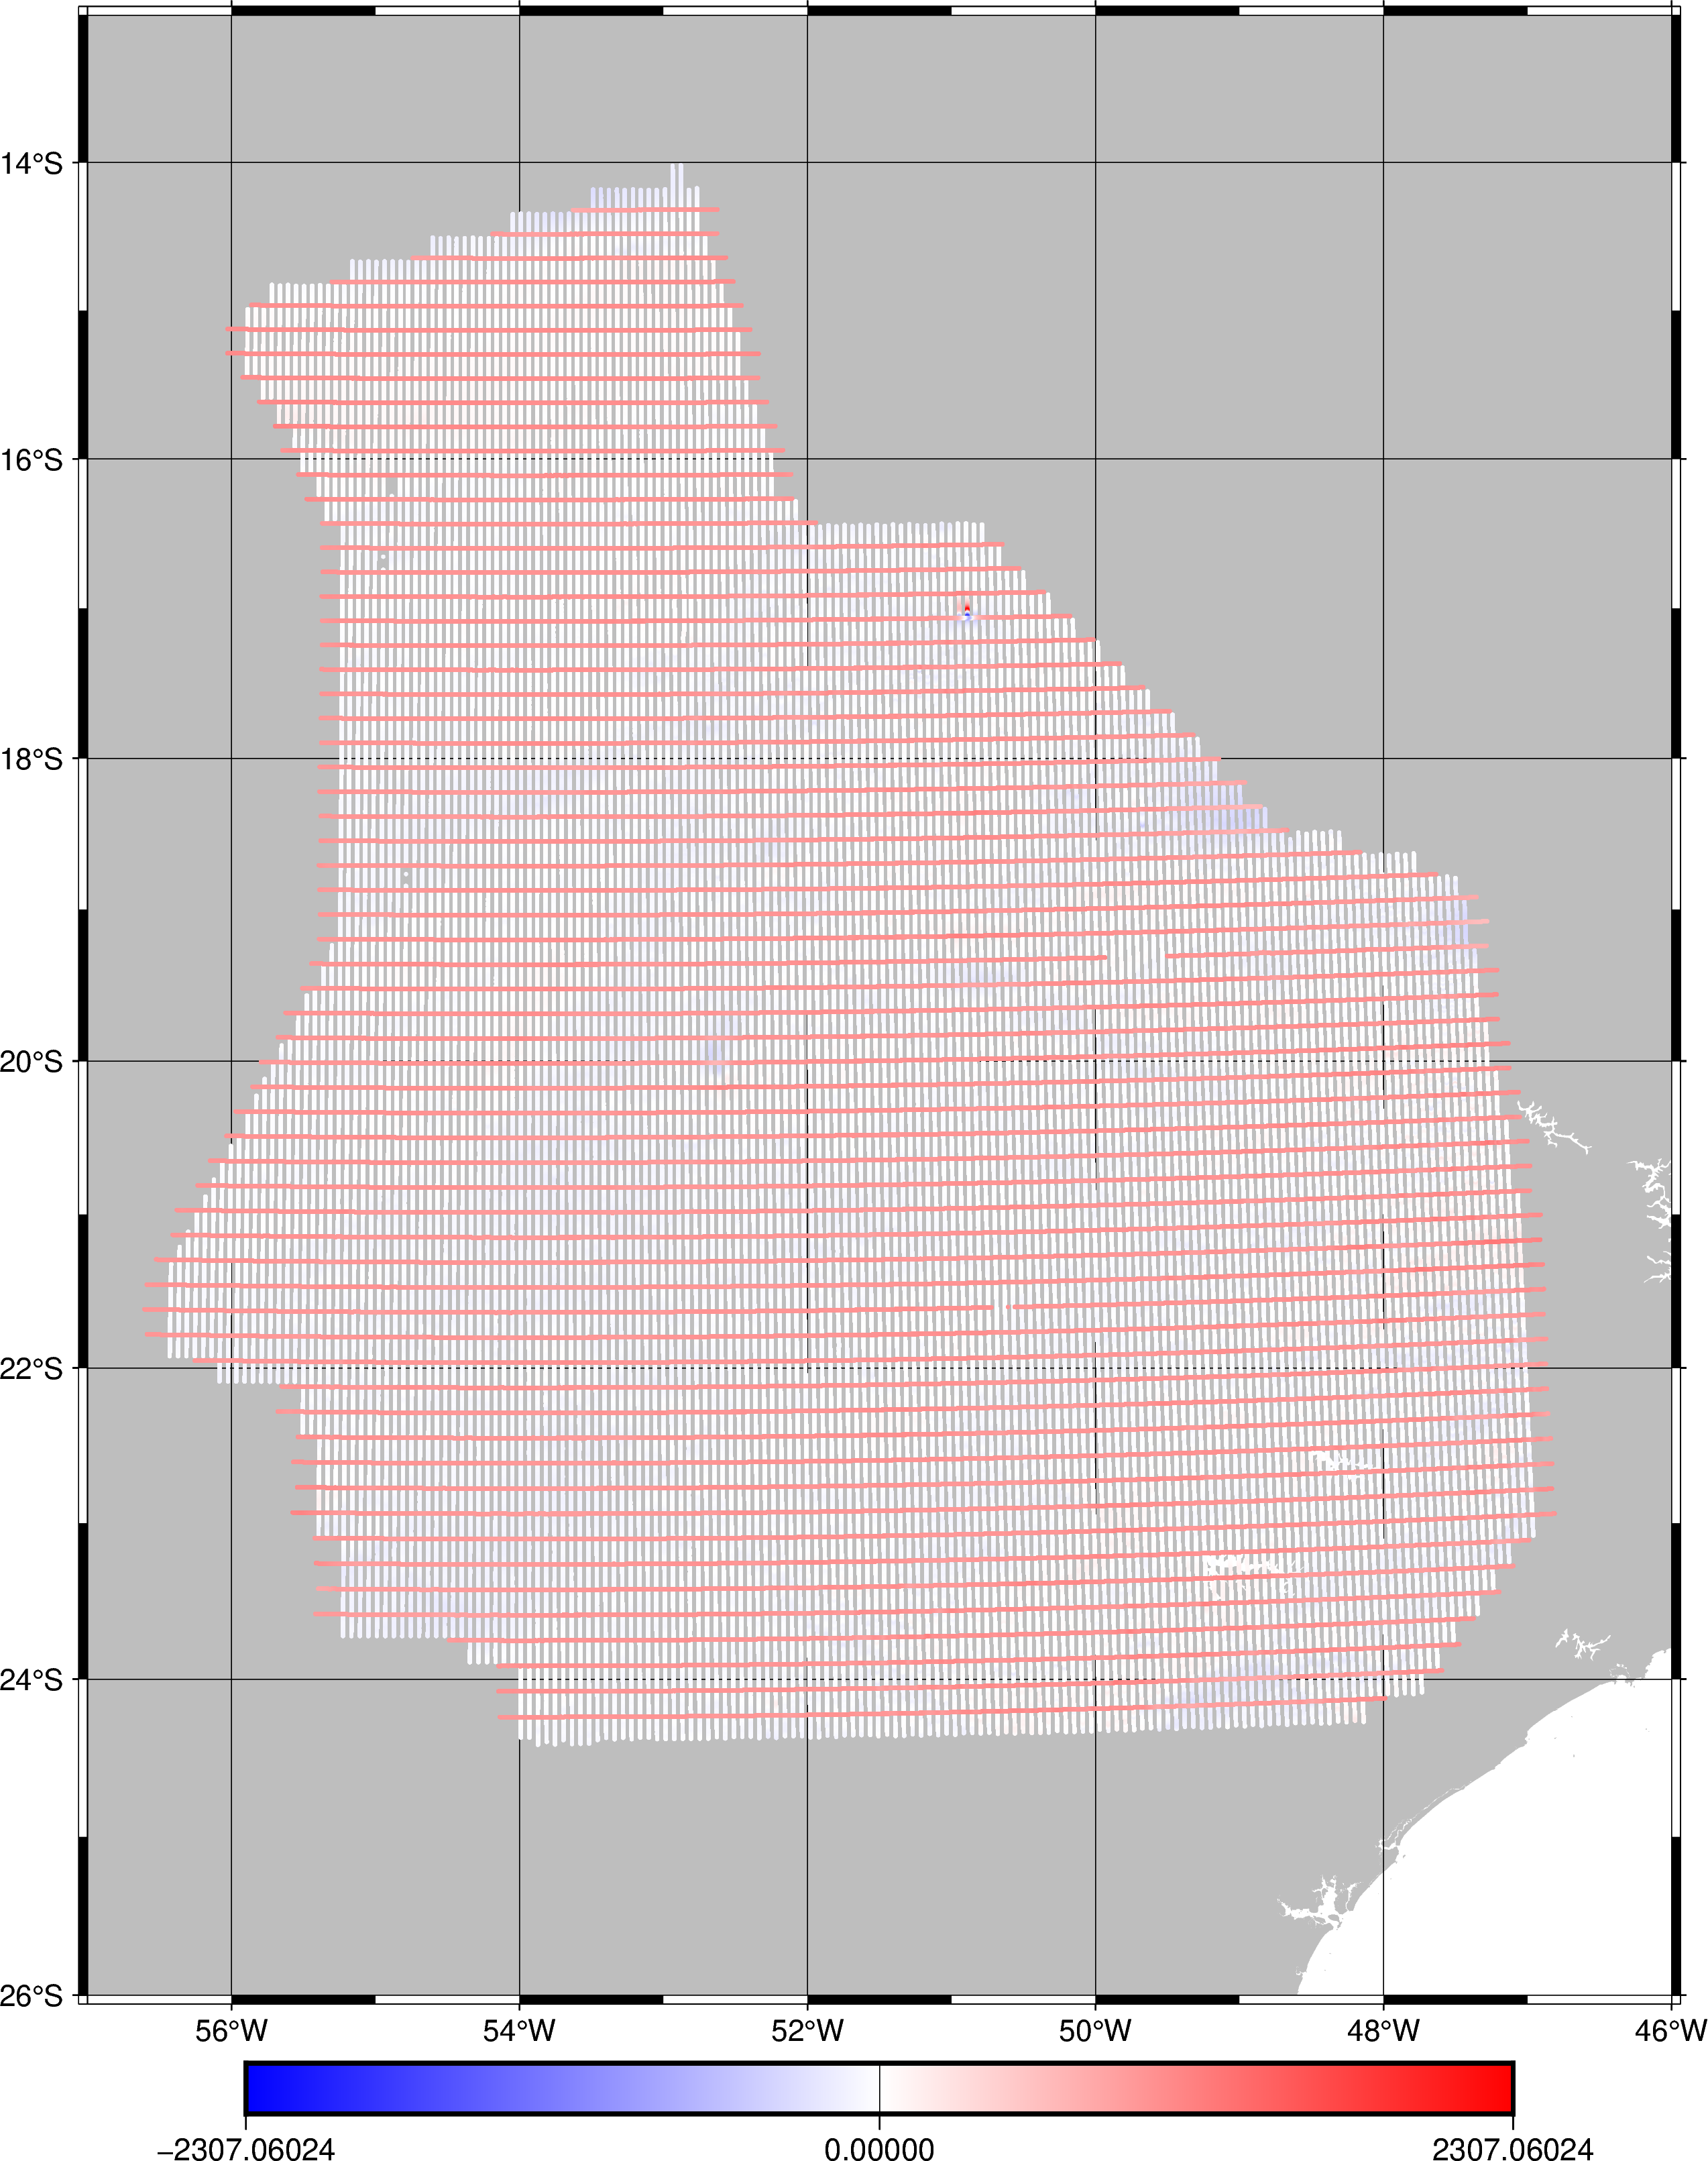

In [5]:
fig = pygmt.Figure()

fig.coast(
    region=[-57, -46, -26, -13],
    projection="M20c", 
    frame="afg",
    land="gray"
)

scale = vd.maxabs(df.MAGIGRF)
pygmt.makecpt(cmap="polar+h", series=[-scale, scale])

fig.plot(
    x=df.LONGITUDE,
    y=df.LATITUDE,
    fill=df.MAGIGRF,
    style="c0.05c",
    cmap=True
)

fig.colorbar(position="JBC")
fig.show(width=700)

Identify and remove the tie flight lines from the dataset.

In [6]:
prefixos = ('19', '29', '39')
df_filtered = df[~df['LINHA'].astype(str).str.startswith(prefixos)].copy()

Using the newly filtered dataset, generate a plot with PyGMT to verify whether the data is now correct.

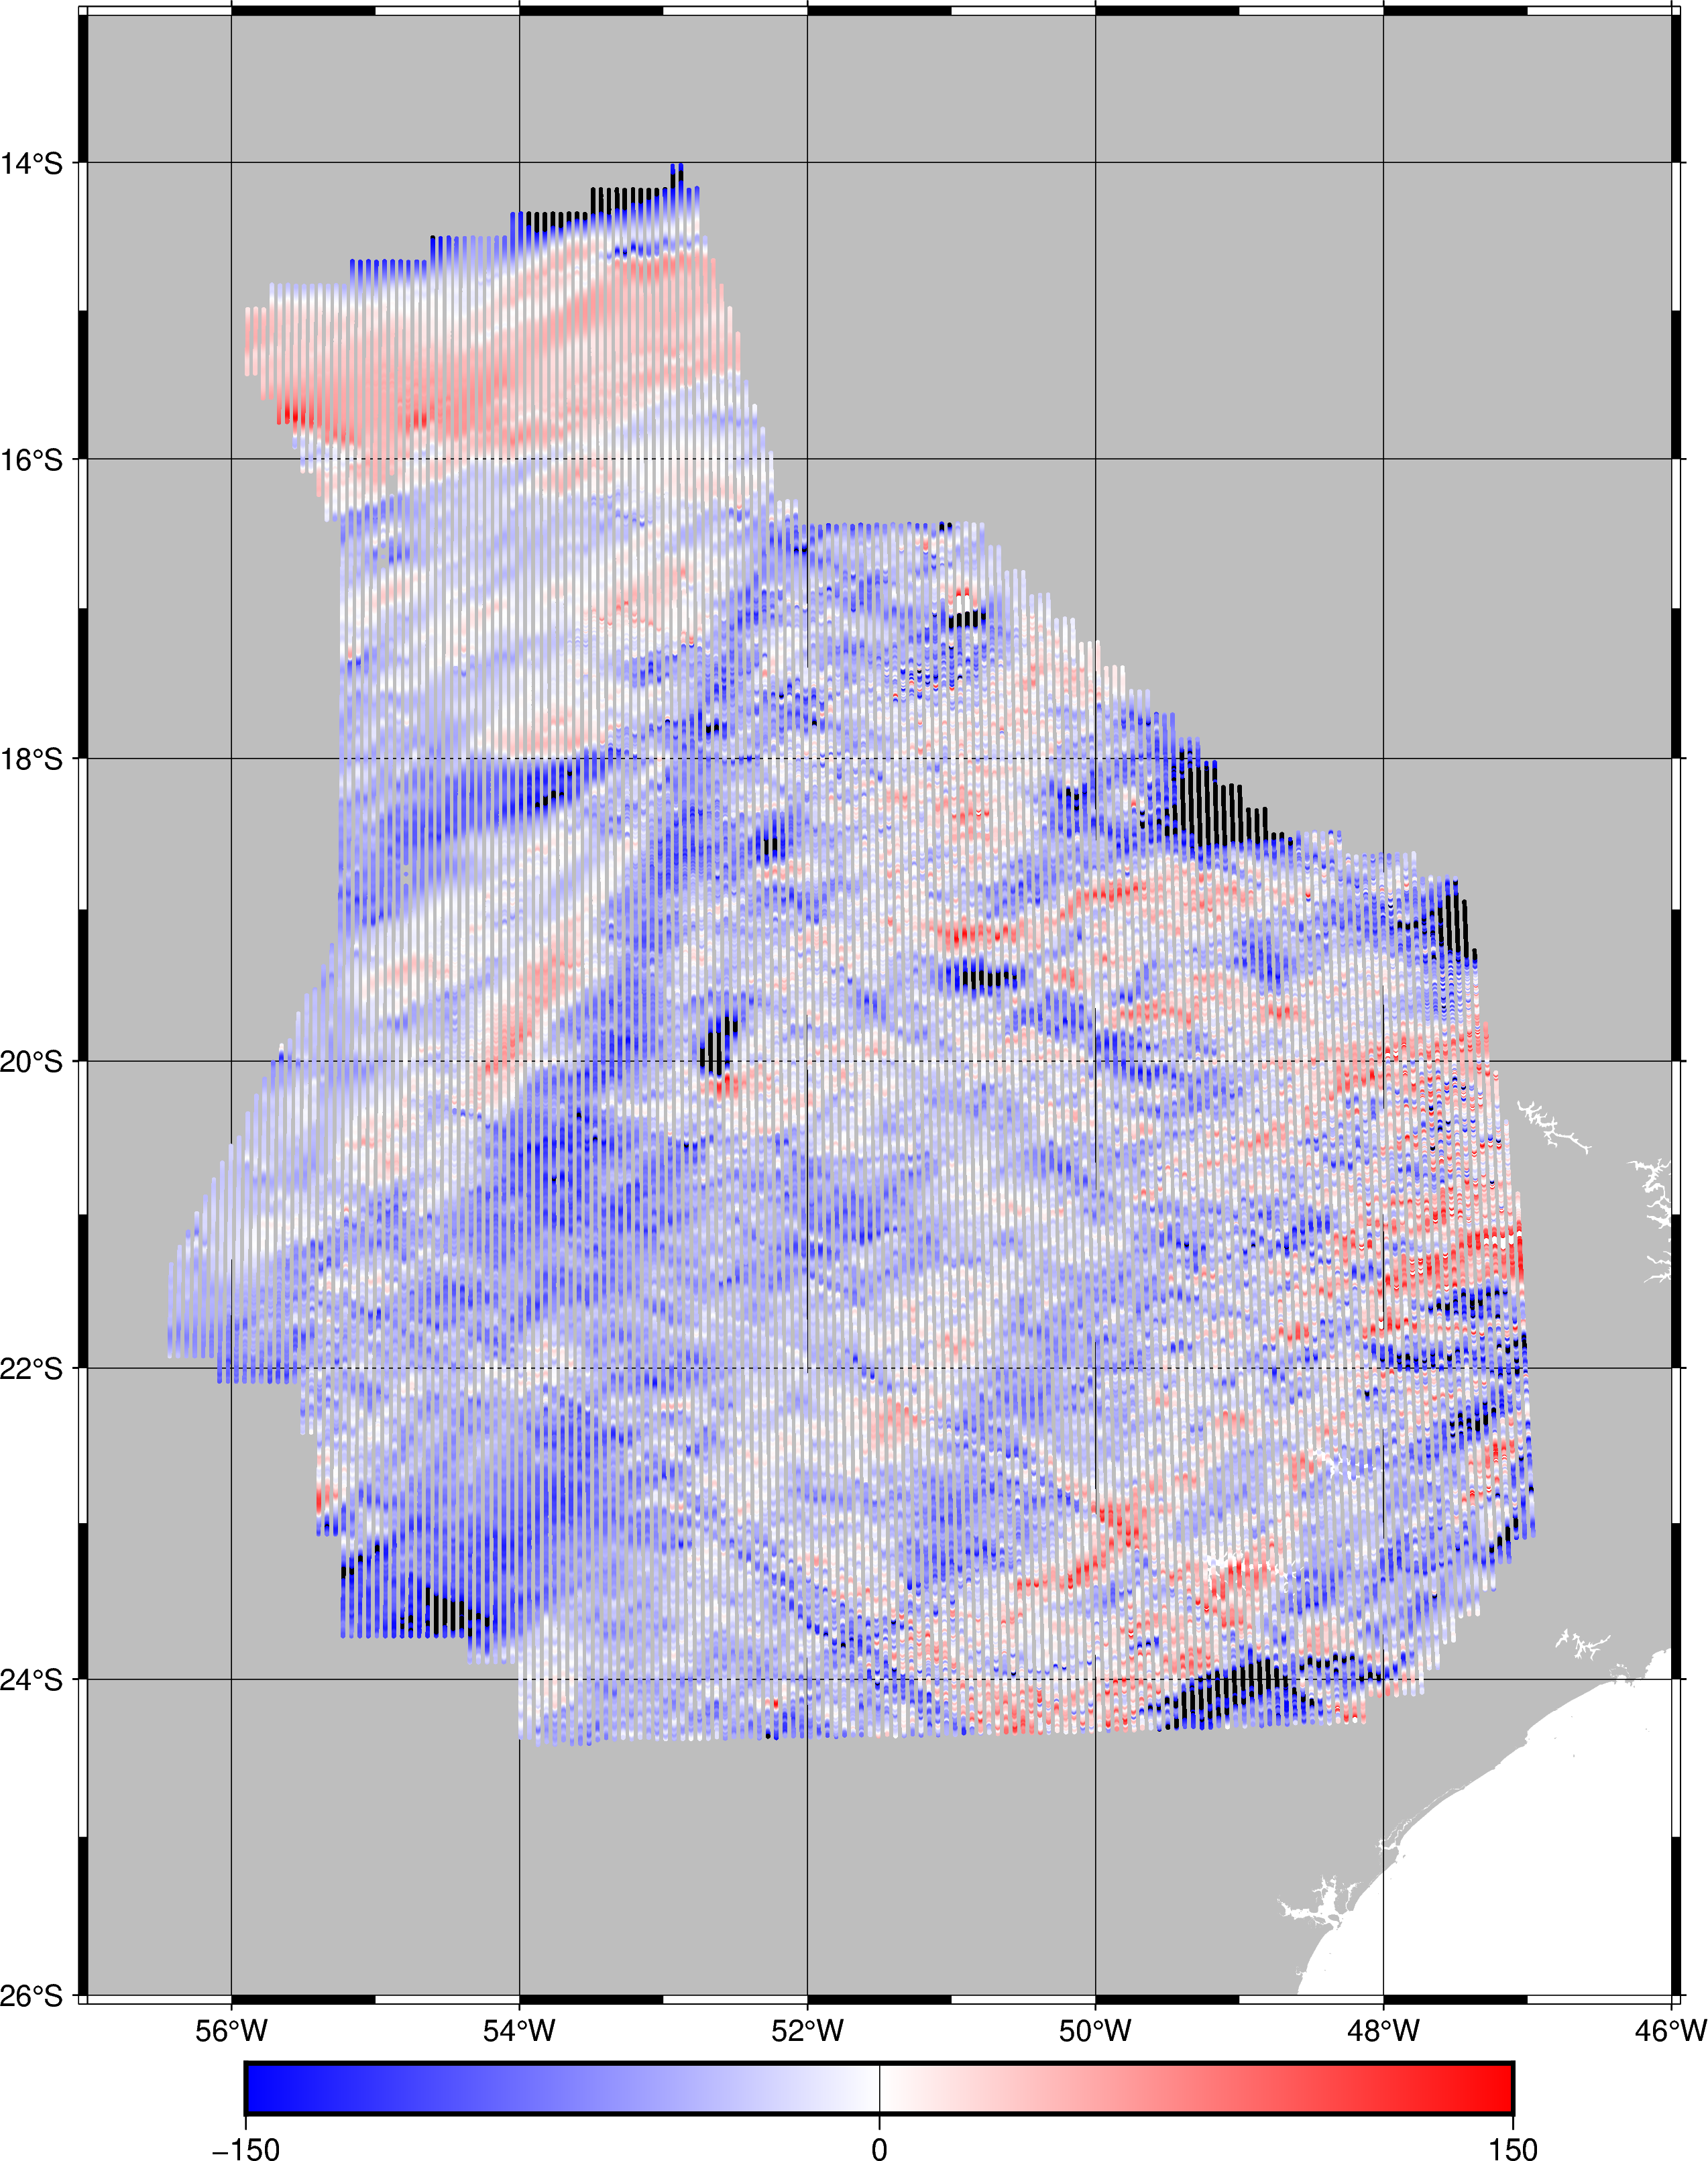

In [12]:
fig = pygmt.Figure()

fig.coast(
    region=[-57, -46, -26, -13],
    projection="M20c", 
    frame="afg",
    land="gray"
)

scale = 150
pygmt.makecpt(cmap="polar+h", series=[-scale, scale])

fig.plot(
    x=df_filtered.LONGITUDE,
    y=df_filtered.LATITUDE,
    fill=df_filtered.MAGIGRF,
    style="c0.05c",
    cmap=True
)

fig.colorbar(position="JBC")
fig.show(width=700)